# 04. YOLO 2D 객체 검출 (Phase 4)

**목표**: KITTI `image_02` 프레임에서 도로 객체(차, 트럭, 버스, 사람, 자전거, 오토바이)의 **2D 바운딩 박스**를 얻는다.
이 박스는 Phase 5 에서 "박스 안에 들어오는 LiDAR 점" 을 고르는 창(window) 역할을 한다.

## 왜 사전학습(pretrained) 모델을 그대로 쓰는가 (학습하지 않는다)

- **사전학습 모델**: 이미 큰 공개 데이터셋(COCO, 12만 장·80 클래스)으로 학습이 끝난 가중치. car / person / bicycle 등 도로 객체를 이미 검출할 수 있다.
- 이 프로젝트의 핵심은 **카메라–LiDAR 융합과 추적**이지 검출기 학습이 아니다. 검출은 "충분히 좋은 기준선(baseline)" 으로 시작하고, Phase 8 의 정량 평가로 한계를 측정한 뒤 필요하면 바꾼다.
- KITTI 라벨로 미세조정(fine-tuning) 하려면 GPU·시간·검증 데이터 분리가 필요하다. 지금은 CPU-first.
- 모델은 **yolov8n** (n = nano, 가장 작은 버전, 약 3.2M 파라미터). CPU 에서도 프레임당 십수 ms 로 돌아간다.

**용어**
- 추론(inference): 학습된 모델에 입력을 넣어 출력을 얻는 것.
- 신뢰도(confidence): 모델이 "이 박스에 이 클래스가 있다" 고 보는 점수 (0~1).
- NMS(Non-Maximum Suppression): 같은 물체에 겹쳐 나온 여러 박스 중 신뢰도가 가장 높은 것만 남기는 후처리. 겹침 정도는 IoU(교집합/합집합) 로 잰다.
- `xyxy`: 박스를 (x1, y1, x2, y2) = (좌상단, 우하단) 픽셀 좌표로 표현하는 형식.

In [1]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset
from perceptrack3d.detection.detector import YoloDetector, load_detections_json
from perceptrack3d.visualization.boxes2d import draw_detections

cfg = load_config()
ds = KittiDataset(cfg)
frame = ds.load_frame(0)
img = frame["image"]                     # (H, W, 3) uint8, BGR (OpenCV 순서)
print("image shape:", img.shape, "dtype:", img.dtype)
print("detection 설정:", cfg["detection"])

image shape: (375, 1242, 3) dtype: uint8
detection 설정: {'model': 'yolov8n.pt', 'conf_threshold': 0.25, 'iou_threshold': 0.45, 'device': 'cpu', 'keep_classes': ['car', 'truck', 'bus', 'person', 'bicycle', 'motorcycle'], 'imgsz': 640}


## 검출기 만들기

`YoloDetector(cfg)` 는 `configs/kitti.yaml` 의 `detection` 절을 읽는다.

| 키 | 의미 |
|---|---|
| `model` | 가중치 파일 이름. 저장소 루트가 아니라 `outputs/models/` 에 두고(없으면 자동 다운로드), `.gitignore` 로 제외된다 |
| `conf_threshold` | 이 신뢰도 미만인 박스는 버림 |
| `iou_threshold` | NMS 에서 "같은 물체" 로 볼 겹침 기준 |
| `imgsz` | 추론 입력 크기. 긴 변을 640 으로 줄이고(letterbox) 나머지는 회색으로 채움 → 1242×375 는 **640×192** 로 축소됨 |
| `keep_classes` | COCO 80 클래스 중 유지할 것 |

**warm-up**: 첫 추론은 연산 커널 초기화 때문에 몇 배 느리다. 생성자에서 더미 이미지로 2회 미리 돌려 두어 이후 측정이 안정되게 한다.

**입력 형식 (공식 문서 확인)**: ultralytics `predict()` 는 `np.ndarray` 를 "HWC, BGR, uint8" 로 받는다. 즉 `cv2.imread` 결과를 색 변환 없이 그대로 넣으면 된다.

In [2]:
t0 = time.perf_counter()
det = YoloDetector(cfg)
print(f"모델 로드 + warm-up: {time.perf_counter() - t0:.2f} s")
print("가중치 경로:", det.model_path)
print("유지 클래스 (COCO id → 이름):", {cid: det.model.names[cid] for cid in det.class_ids})

모델 로드 + warm-up: 0.85 s
가중치 경로: /home/ingon/Projects/PercepTrack3D/outputs/models/yolov8n.pt
유지 클래스 (COCO id → 이름): {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


## 프레임 1장 검출

출력은 `Detection2D` 리스트다. 각 항목:

| 필드 | 타입/shape | 의미 |
|---|---|---|
| `frame_id` | int | 프레임 번호 |
| `class_name`, `class_id` | str, int | COCO 이름과 id (예: car = 2) |
| `confidence` | float ∈ [0, 1] | 신뢰도 |
| `xyxy` | `np.float32 (4,)` | image_02 픽셀 좌표 (x1, y1, x2, y2). **원점 = 좌상단, x 는 오른쪽, y 는 아래** |

좌표계 주의: 이 박스는 **픽셀(img) 프레임**이다. 3D 로 가려면 Phase 3 의 투영으로 LiDAR 점을 같은 픽셀 프레임에 가져와 비교해야 한다.

In [3]:
dets = det.detect(img, frame_id=0)
print(f"검출 {len(dets)}개 (신뢰도 내림차순)")
for d in dets:
    print(f"  {d.class_name:8s} id={d.class_id} conf={d.confidence:.3f} xyxy={np.round(d.xyxy, 1)}  dtype={d.xyxy.dtype} shape={d.xyxy.shape}")

검출 3개 (신뢰도 내림차순)
  car      id=2 conf=0.792 xyxy=[      255.7       174.3       302.6       201.1]  dtype=float32 shape=(4,)
  car      id=2 conf=0.493 xyxy=[      569.8       173.5       609.6       208.1]  dtype=float32 shape=(4,)
  car      id=2 conf=0.405 xyxy=[      321.2       177.8         355       196.9]  dtype=float32 shape=(4,)


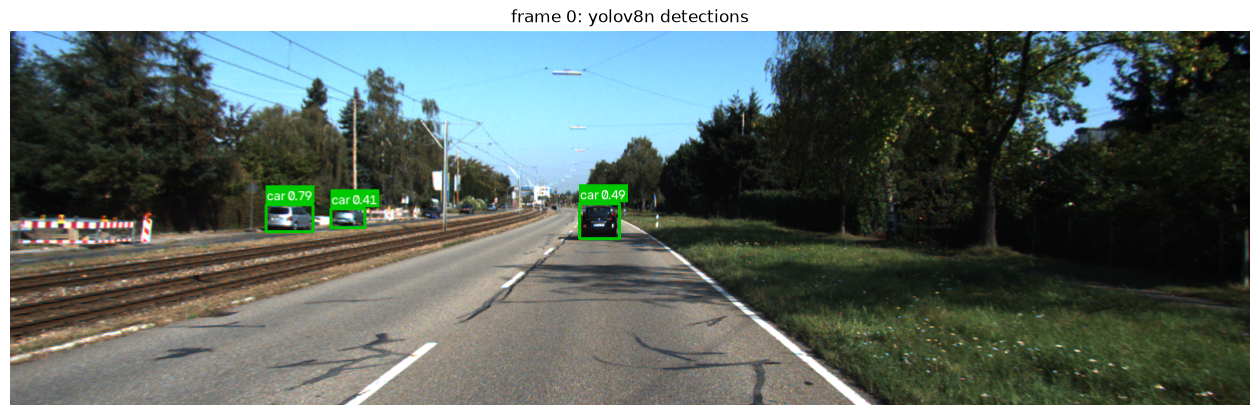

In [4]:
vis = draw_detections(img, dets)                  # BGR 그대로 그림
plt.figure(figsize=(16, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))   # matplotlib 은 RGB 를 기대하므로 변환
plt.title("frame 0: yolov8n detections")
plt.axis("off")
plt.show()

## COCO 클래스 vs KITTI 클래스

모델은 COCO 이름을 내고, 정답(tracklet_labels.xml) 은 KITTI 이름을 쓴다. **1:1 이 아니다.**

| COCO (모델 출력) | KITTI tracklet `objectType` | 대응 규칙 / 문제 |
|---|---|---|
| car | Car, **Van** | 승합차(Van)도 대개 car 로 나옴. 평가 시 car ↔ {Car, Van} 으로 묶어야 함 |
| truck | Truck, (Van 일부) | 배송 밴이 truck 으로 나오기도 함 |
| bus | (Truck / Van 오검) | KITTI 에 Bus 타입은 있으나 이 시퀀스엔 없음. 큰 밴·트럭이 bus 로 혼동됨 |
| person | Pedestrian, Person_sitting | 서 있는 사람은 잘 대응. 자전거 탄 사람도 person 으로 나올 수 있음 |
| bicycle + person | **Cyclist** | KITTI 는 "자전거 탄 사람" 을 한 객체로 라벨. COCO 는 사람과 자전거를 따로 검출하므로 두 박스를 합쳐야 Cyclist 하나가 됨 |
| motorcycle | (없음) | 이 시퀀스에 없음 |
| — | Tram, Misc, DontCare | COCO 에 대응 클래스 없음. 평가에서 제외 |

아래 셀에서 297 프레임 전체 결과(`outputs/phase4/detections.json`) 를 읽어 클래스별 개수를 센다. 이 JSON 을 읽는 함수가 Phase 5 융합 팀이 쓸 인터페이스다.

In [5]:
from collections import Counter
from pathlib import Path

all_dets = load_detections_json(Path(cfg["outputs"]["dir"]) / "phase4" / "detections.json")
flat = [d for v in all_dets.values() for d in v]
print("프레임 수:", len(all_dets), " 총 검출:", len(flat))
print("클래스별:", Counter(d.class_name for d in flat).most_common())
print("신뢰도 분포: min %.2f / median %.2f / max %.2f" % tuple(np.percentile([d.confidence for d in flat], [0, 50, 100])))

프레임 수: 297  총 검출: 1325
클래스별: [('car', 1254), ('truck', 37), ('person', 23), ('bus', 10), ('bicycle', 1)]
신뢰도 분포: min 0.25 / median 0.55 / max 0.96


## 추론 시간 측정

- `time.perf_counter()` 로 `predict()` 한 번(전처리 letterbox + 신경망 순전파 + NMS) 을 잰다. 이미지 디스크 로드는 제외.
- warm-up 은 생성자에서 끝났으므로 여기서 재는 20회는 모두 "안정 상태" 다.
- 성능 수치는 항상 **하드웨어·입력 크기·프레임 수·측정 구간**과 함께 적는다 (`outputs/phase4/runtime.md`).

In [6]:
import torch, ultralytics, os
times = []
for _ in range(20):
    _, ms = det.detect_timed(img, frame_id=0)
    times.append(ms)
times = np.array(times)
print(f"CPU threads={torch.get_num_threads()} / torch {torch.__version__} / ultralytics {ultralytics.__version__} / imgsz={det.imgsz}")
print(f"20회: 평균 {times.mean():.2f} ms, 중앙값 {np.median(times):.2f} ms, 최소 {times.min():.2f}, 최대 {times.max():.2f}  →  약 {1000/np.median(times):.0f} FPS")

CPU threads=8 / torch 2.14.0+cpu / ultralytics 8.4.142 / imgsz=640
20회: 평균 10.83 ms, 중앙값 10.74 ms, 최소 9.24, 최대 15.57  →  약 93 FPS


## 실패 사례

정답(GT) 과 비교해 고른 대표 실패 2장. 전체 5장과 원인 정리는 `outputs/phase4/failures/README.md`.

1. **프레임 186 — 자전거 탄 사람(Cyclist) 미검출**: 우측 가로등 기둥 옆의 자전거 탄 사람이 person 으로도 bicycle 로도 안 나온다. 기둥과 겹쳐 실루엣이 끊기고, COCO 에는 Cyclist 클래스가 없어 두 클래스 모두 신뢰도가 0.25 를 넘지 못했다.
2. **프레임 168 — 이중 검출·클래스 혼동**: 좌측 UPS 밴에 `truck 0.77` 과 `bus 0.54` 박스가 겹쳐 나온다. NMS 가 **클래스별**로 동작해 클래스가 다른 겹친 박스는 서로 억제하지 않기 때문이다. 융합 단계에서 같은 물체에 3D 결과가 2개 생길 수 있다.

그 외 흔한 실패: 40 m 이상 원거리 소형 차량(입력 축소로 10 px 대), 주차 차량 열의 가림, 이미지 경계에서 잘린 객체(검출은 되지만 박스 중심이 치우침), 공사 표지판을 person 으로 오검출.

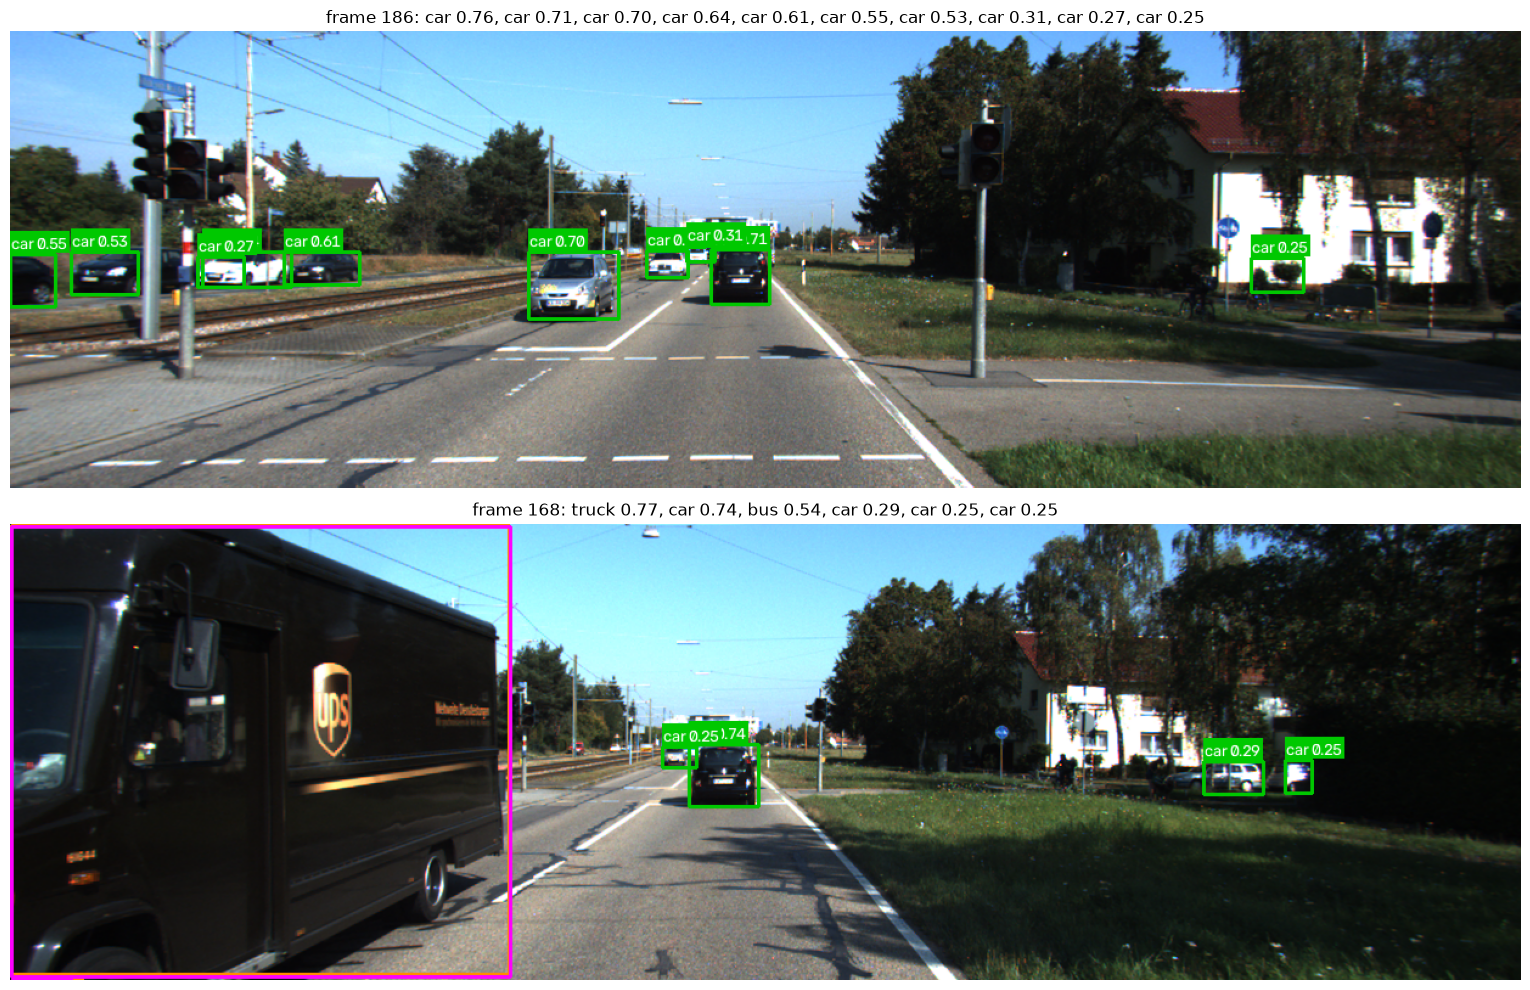

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, fid in zip(axes, [186, 168]):
    f = ds.load_frame(fid)
    ax.imshow(cv2.cvtColor(draw_detections(f["image"], all_dets[fid]), cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {fid}: " + ", ".join(f"{d.class_name} {d.confidence:.2f}" for d in all_dets[fid]))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 정리

- 입력: `(375, 1242, 3) uint8 BGR` → 출력: `Detection2D` 리스트 (`xyxy float32 (4,)` 픽셀, 신뢰도, COCO 클래스).
- 같은 이미지를 두 번 넣으면 같은 박스가 나온다 (`tests/test_detector.py::test_detect_deterministic`). 추론에는 난수가 없으므로 `torch.manual_seed` 는 필요 없다.
- 한계: 원거리 소형 객체, 가림, Cyclist, 클래스별 NMS 이중 검출. 정량 수치는 Phase 8 에서.

## 자가 점검 질문

1. `xyxy` 의 네 값은 어느 좌표계의 무엇이며, 원점과 축 방향은 어디인가? 이 값을 LiDAR 점과 비교하려면 무엇이 먼저 필요한가?
2. `imgsz=640` 일 때 1242×375 이미지는 내부적으로 몇 픽셀로 줄어드는가? 이것이 40 m 앞 차량 검출에 어떤 영향을 주는가?
3. COCO 의 person + bicycle 검출을 KITTI 의 Cyclist 와 비교하려면 어떤 규칙이 필요한가? 그리고 `truck 0.77` / `bus 0.54` 가 한 물체에 겹쳐 나온 이유는 무엇인가?